# 06. Fixed Income Performance Attribution Proxy

This notebook analyzes why the frozen regime strategy produced lower long-run Sharpe but smaller maximum drawdown than the static benchmarks.

The analysis uses reference-duration proxies rather than historical bond-level attribution.

## Decomposition

Monthly realized gross return is decomposed as:

\[
Gross\ Return
=
Rate\ Contribution\ Proxy
+
Credit\ Contribution\ Proxy
+
Residual
\]

Net return additionally subtracts transaction costs.

The residual includes effects not captured by the simplified rate and credit proxies, including carry, roll-down, convexity, changing historical duration, spread-basis differences, ETF tracking, and other pricing effects.

Therefore, this analysis is descriptive and should not be interpreted as exact institutional bond-level P&L attribution.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

print("Project root  :", PROJECT_ROOT)
print("Processed dir :", PROCESSED_DIR)

Project root  : c:\Users\minha\Desktop\global-fixed-income-strategy
Processed dir : c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed


In [3]:
PORTFOLIO_DESIGN_PATH = (
    PROCESSED_DIR
    / "fixed_income_portfolio_design.csv"
)

BACKTEST_PATH = (
    PROCESSED_DIR
    / "fixed_income_backtest_results.csv"
)

RISK_SNAPSHOT_PATH = (
    PROCESSED_DIR
    / "fixed_income_risk_snapshot.csv"
)


portfolio_design = pd.read_csv(
    PORTFOLIO_DESIGN_PATH,
    index_col="Date",
    parse_dates=True,
)

strategy_bt = pd.read_csv(
    BACKTEST_PATH,
    index_col="Date",
    parse_dates=True,
)

risk_snapshot = pd.read_csv(
    RISK_SNAPSHOT_PATH,
    index_col=0,
)


portfolio_design.index.name = "Date"
strategy_bt.index.name = "Date"

print(
    "Portfolio design:",
    portfolio_design.shape
)

print(
    "Strategy backtest:",
    strategy_bt.shape
)

print(
    "Risk snapshot:",
    risk_snapshot.shape
)

print(
    "\nBacktest period:",
    strategy_bt.index.min(),
    "to",
    strategy_bt.index.max()
)

Portfolio design: (223, 37)
Strategy backtest: (219, 6)
Risk snapshot: (5, 5)

Backtest period: 2008-05-31 00:00:00 to 2026-07-31 00:00:00


In [4]:
ETF_TICKERS = [
    "SHY",
    "IEF",
    "TLT",
    "LQD",
    "HYG",
]

WEIGHT_COLUMNS = [
    f"{ticker}_weight"
    for ticker in ETF_TICKERS
]

required_columns = [
    "US2Y",
    "US5Y",
    "US10Y",
    "US30Y",
    "BAA10Y",
    "Applied_Regime",
    *WEIGHT_COLUMNS,
]

missing_columns = [
    col
    for col in required_columns
    if col not in portfolio_design.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}"
)

assert (
    risk_snapshot.index.tolist()
    == ETF_TICKERS
)

assert (
    strategy_bt.index
    .isin(portfolio_design.index)
    .all()
)

print(
    "Attribution input validation passed."
)

Attribution input validation passed.


## 1. Reference Rate Mapping

Each ETF is mapped to a Treasury maturity that approximately reflects its interest-rate exposure:

| ETF | Reference Treasury Yield |
|---|---|
| SHY | 2Y |
| IEF | 10Y |
| TLT | 30Y |
| LQD | 10Y |
| HYG | 5Y |

The mapping is intentionally simple and is not estimated from historical ETF performance.

In [5]:
RATE_SERIES_MAP = {
    "SHY": "US2Y",
    "IEF": "US10Y",
    "TLT": "US30Y",
    "LQD": "US10Y",
    "HYG": "US5Y",
}

RATE_SERIES_MAP

{'SHY': 'US2Y', 'IEF': 'US10Y', 'TLT': 'US30Y', 'LQD': 'US10Y', 'HYG': 'US5Y'}

In [6]:
attribution_base = (
    portfolio_design.copy()
)

for yield_column in [
    "US2Y",
    "US5Y",
    "US10Y",
    "US30Y",
]:

    attribution_base[
        f"{yield_column}_1m_change_bps"
    ] = (
        attribution_base[
            yield_column
        ].diff()
        * 100
    )


attribution_base[
    "BAA10Y_1m_change_bps"
] = (
    attribution_base[
        "BAA10Y"
    ].diff()
    * 100
)


attribution_base = (
    attribution_base.loc[
        strategy_bt.index
    ].copy()
)

attribution_base[
    [
        "US2Y_1m_change_bps",
        "US5Y_1m_change_bps",
        "US10Y_1m_change_bps",
        "US30Y_1m_change_bps",
        "BAA10Y_1m_change_bps",
    ]
].head()

,US2Y_1m_change_bps,US5Y_1m_change_bps,US10Y_1m_change_bps,US30Y_1m_change_bps,BAA10Y_1m_change_bps
Date,,,,,
2008-05-31,37.0,38.0,29.0,23.0,-10.0
2008-06-30,-3.0,-7.0,-7.0,-19.0,5.0
2008-07-31,-11.0,-9.0,0.0,6.0,17.0
2008-08-31,-16.0,-15.0,-16.0,-16.0,7.0
2008-09-30,-36.0,-12.0,2.0,-12.0,71.0


In [7]:
change_columns = [
    "US2Y_1m_change_bps",
    "US5Y_1m_change_bps",
    "US10Y_1m_change_bps",
    "US30Y_1m_change_bps",
    "BAA10Y_1m_change_bps",
]

assert (
    attribution_base[
        change_columns
    ].notna().all().all()
)

print(
    "Monthly rate/spread change validation passed."
)

Monthly rate/spread change validation passed.


In [8]:
asset_rate_proxy = pd.DataFrame(
    index=attribution_base.index,
    columns=ETF_TICKERS,
    dtype=float,
)

for ticker in ETF_TICKERS:

    rate_column = (
        RATE_SERIES_MAP[ticker]
    )

    duration = (
        risk_snapshot.loc[
            ticker,
            "Effective_Duration"
        ]
    )

    delta_y = (
        attribution_base[
            f"{rate_column}_1m_change_bps"
        ]
        / 10_000
    )

    asset_rate_proxy[
        ticker
    ] = (
        -duration
        * delta_y
    )

asset_rate_proxy.tail()

,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2026-03-31,-0.007298,-0.022506,-0.035880,-0.025542,-0.012095
2026-04-30,-0.001602,-0.006820,-0.014950,-0.007740,-0.002950
2026-05-31,-0.001780,-0.003410,-0.001495,-0.003870,-0.003245
2026-06-30,-0.002848,0.000682,0.011960,0.000774,-0.001770
2026-07-31,-0.002492,-0.021142,-0.053820,-0.023994,-0.007670


In [9]:
asset_credit_proxy = pd.DataFrame(
    0.0,
    index=attribution_base.index,
    columns=ETF_TICKERS,
)

credit_change_decimal = (
    attribution_base[
        "BAA10Y_1m_change_bps"
    ]
    / 10_000
)

for ticker in [
    "LQD",
    "HYG",
]:

    spread_duration_proxy = (
        risk_snapshot.loc[
            ticker,
            "Spread_Duration_Proxy"
        ]
    )

    asset_credit_proxy[
        ticker
    ] = (
        -spread_duration_proxy
        * credit_change_decimal
    )

asset_credit_proxy.tail()

,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2026-03-31,0.0,0.0,0.0,0.000774,0.000295
2026-04-30,0.0,0.0,0.0,0.006966,0.002655
2026-05-31,0.0,0.0,0.0,0.010062,0.003835
2026-06-30,0.0,0.0,0.0,0.003096,0.001180
2026-07-31,0.0,0.0,0.0,-0.007740,-0.002950


In [10]:
example_tightening = (
    attribution_base[
        "BAA10Y_1m_change_bps"
    ] < 0
)

example_widening = (
    attribution_base[
        "BAA10Y_1m_change_bps"
    ] > 0
)

if example_tightening.any():

    tightening_date = (
        attribution_base.index[
            example_tightening
        ][0]
    )

    assert (
        asset_credit_proxy.loc[
            tightening_date,
            "LQD"
        ] > 0
    )


if example_widening.any():

    widening_date = (
        attribution_base.index[
            example_widening
        ][0]
    )

    assert (
        asset_credit_proxy.loc[
            widening_date,
            "LQD"
        ] < 0
    )


print(
    "Rate / credit contribution sign validation passed."
)

Rate / credit contribution sign validation passed.


In [11]:
strategy_weights = (
    attribution_base[
        WEIGHT_COLUMNS
    ]
    .copy()
)

strategy_weights.columns = (
    ETF_TICKERS
)

assert np.allclose(
    strategy_weights.sum(axis=1),
    1.0
)

strategy_weights.head()

,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-05-31,0.55,0.25,0.0,0.2,0.0
2008-06-30,0.35,0.15,0.0,0.3,0.2
2008-07-31,0.35,0.15,0.0,0.3,0.2
2008-08-31,0.55,0.25,0.0,0.2,0.0
2008-09-30,0.10,0.30,0.4,0.2,0.0


In [12]:
portfolio_rate_proxy = (
    strategy_weights
    * asset_rate_proxy
).sum(axis=1)

portfolio_credit_proxy = (
    strategy_weights
    * asset_credit_proxy
).sum(axis=1)

attribution = pd.DataFrame(
    index=strategy_bt.index
)

attribution[
    "Rate_Contribution_Proxy"
] = portfolio_rate_proxy

attribution[
    "Credit_Contribution_Proxy"
] = portfolio_credit_proxy

attribution[
    "Gross_Return"
] = strategy_bt[
    "Gross_Return"
]

attribution[
    "Residual"
] = (
    attribution[
        "Gross_Return"
    ]
    - attribution[
        "Rate_Contribution_Proxy"
    ]
    - attribution[
        "Credit_Contribution_Proxy"
    ]
)

attribution[
    "Transaction_Cost_Contribution"
] = (
    -strategy_bt[
        "Transaction_Cost"
    ]
)

attribution[
    "Net_Return"
] = strategy_bt[
    "Net_Return"
]

attribution[
    "Applied_Regime"
] = attribution_base[
    "Applied_Regime"
]

attribution[
    "Turnover"
] = strategy_bt[
    "Turnover"
]

attribution.head()

,Rate_Contribution_Proxy,Credit_Contribution_Proxy,Gross_Return,Residual,Transaction_Cost_Contribution,Net_Return,Applied_Regime,Turnover
Date,,,,,,,,
2008-05-31,-0.013056,0.001548,-0.010757,0.000751,-0.000000,-0.010757,Rising / Widening,0.000000
2008-06-30,0.002941,-0.001456,-0.008647,-0.010132,-0.000302,-0.008949,Rising / Tightening,0.302283
2008-07-31,0.001216,-0.004950,0.004952,0.008686,-0.000007,0.004945,Rising / Tightening,0.006962
2008-08-31,0.006771,-0.001084,0.006671,0.000984,-0.000300,0.006371,Rising / Widening,0.299876
2008-09-30,0.007098,-0.010991,-0.015200,-0.011308,-0.000449,-0.015649,Falling / Widening,0.448903


In [13]:
attribution[
    "Reconstructed_Net_Return"
] = (
    attribution[
        "Rate_Contribution_Proxy"
    ]
    + attribution[
        "Credit_Contribution_Proxy"
    ]
    + attribution[
        "Residual"
    ]
    + attribution[
        "Transaction_Cost_Contribution"
    ]
)

max_reconciliation_error = (
    (
        attribution[
            "Reconstructed_Net_Return"
        ]
        - attribution[
            "Net_Return"
        ]
    )
    .abs()
    .max()
)

print(
    "Maximum reconciliation error:",
    max_reconciliation_error
)

assert np.allclose(
    attribution[
        "Reconstructed_Net_Return"
    ],
    attribution[
        "Net_Return"
    ]
)

print(
    "\nMonthly attribution reconciliation passed."
)

Maximum reconciliation error: 1.1102230246251565e-16

Monthly attribution reconciliation passed.


## 2. Long-Run Arithmetic Contribution

Monthly contribution proxies are annualized using their arithmetic means.

These values explain the average monthly return structure and should not be interpreted as an additive decomposition of CAGR.

In [14]:
contribution_columns = [
    "Rate_Contribution_Proxy",
    "Credit_Contribution_Proxy",
    "Residual",
    "Transaction_Cost_Contribution",
]

annualized_contribution = (
    attribution[
        contribution_columns
    ].mean()
    * 12
)

annualized_net_return = (
    attribution[
        "Net_Return"
    ].mean()
    * 12
)

contribution_summary = pd.DataFrame(
    {
        "Annualized_Arithmetic_Contribution": (
            annualized_contribution
        )
    }
)

contribution_summary.loc[
    "Actual Net Return",
    "Annualized_Arithmetic_Contribution"
] = annualized_net_return

contribution_summary[
    "Percent"
] = (
    contribution_summary[
        "Annualized_Arithmetic_Contribution"
    ]
    * 100
)

contribution_summary.round(3)

,Annualized_Arithmetic_Contribution,Percent
Rate_Contribution_Proxy,-0.003,-0.321
Credit_Contribution_Proxy,0.003,0.325
Residual,0.034,3.414
Transaction_Cost_Contribution,-0.002,-0.196
Actual Net Return,0.032,3.223


In [15]:
component_sum = (
    annualized_contribution.sum()
)

print(
    "Annualized component sum:",
    component_sum
)

print(
    "Annualized actual net return:",
    annualized_net_return
)

assert np.isclose(
    component_sum,
    annualized_net_return
)

print(
    "\nLong-run contribution validation passed."
)

Annualized component sum: 0.03222615565212487
Annualized actual net return: 0.03222615565212465

Long-run contribution validation passed.


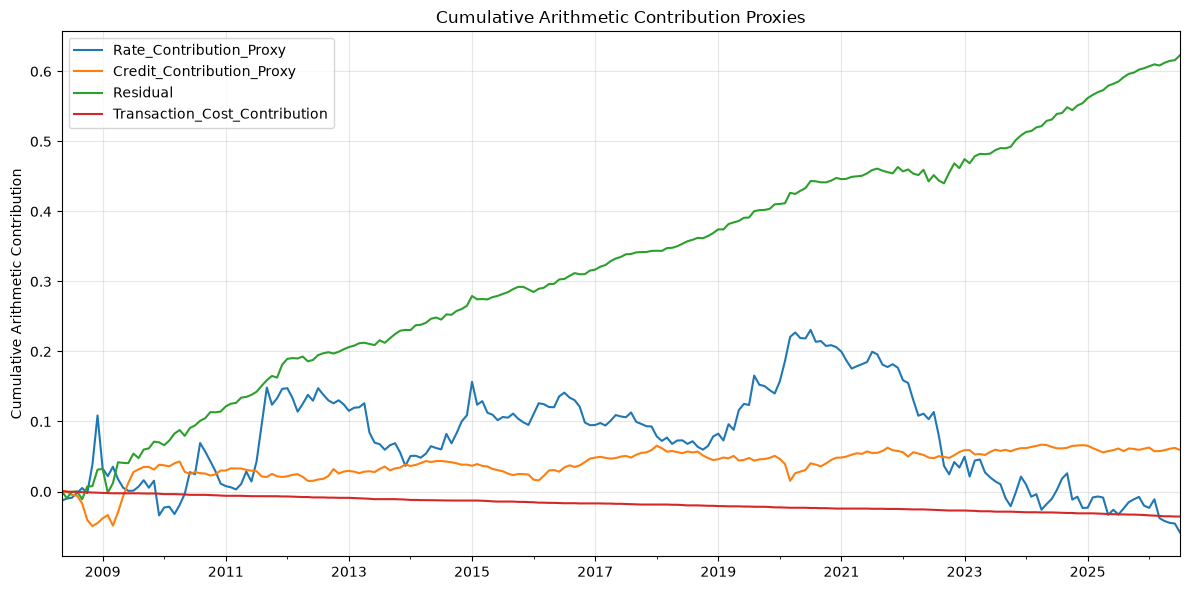

In [16]:
cumulative_contribution = (
    attribution[
        contribution_columns
    ]
    .cumsum()
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

cumulative_contribution.plot(
    ax=ax
)

ax.set_title(
    "Cumulative Arithmetic Contribution Proxies"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Cumulative Arithmetic Contribution"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
regime_summary = (
    attribution
    .groupby(
        "Applied_Regime"
    )
    .agg(
        Months=(
            "Net_Return",
            "size"
        ),

        Avg_Monthly_Net_Return=(
            "Net_Return",
            "mean"
        ),

        Avg_Rate_Proxy=(
            "Rate_Contribution_Proxy",
            "mean"
        ),

        Avg_Credit_Proxy=(
            "Credit_Contribution_Proxy",
            "mean"
        ),

        Avg_Residual=(
            "Residual",
            "mean"
        ),

        Avg_Transaction_Cost=(
            "Transaction_Cost_Contribution",
            "mean"
        ),

        Avg_Turnover=(
            "Turnover",
            "mean"
        ),
    )
)

regime_display = (
    regime_summary.copy()
)

percentage_cols = [
    "Avg_Monthly_Net_Return",
    "Avg_Rate_Proxy",
    "Avg_Credit_Proxy",
    "Avg_Residual",
    "Avg_Transaction_Cost",
    "Avg_Turnover",
]

for col in percentage_cols:

    regime_display[col] *= 100

regime_display.round(3)

,Months,Avg_Monthly_Net_Return,Avg_Rate_Proxy,Avg_Credit_Proxy,Avg_Residual,Avg_Transaction_Cost,Avg_Turnover
Applied_Regime,,,,,,,
Falling / Tightening,46,0.342,0.008,0.093,0.256,-0.015,15.392
Falling / Widening,57,0.272,-0.031,-0.010,0.330,-0.019,18.572
Rising / Tightening,82,0.303,-0.025,0.047,0.294,-0.013,12.831
Rising / Widening,30,0.317,0.097,-0.037,0.278,-0.022,21.700
Stable / Mixed,4,-1.682,-1.335,-0.123,-0.200,-0.025,25.042


In [18]:
STRESS_PERIODS = {
    "Global Financial Crisis": (
        "2008-05-31",
        "2009-06-30",
    ),

    "COVID Shock": (
        "2020-02-29",
        "2020-05-31",
    ),

    "2022 Rate Shock": (
        "2022-01-31",
        "2022-12-31",
    ),
}

In [19]:
stress_attribution_results = []

for period_name, (
    start,
    end,
) in STRESS_PERIODS.items():

    period = (
        attribution.loc[
            start:end
        ]
    )

    actual_cumulative_return = (
        (
            1.0
            + period[
                "Net_Return"
            ]
        ).prod()
        - 1.0
    )

    stress_attribution_results.append(
        {
            "Period":
                period_name,

            "Months":
                len(period),

            "Actual_Cumulative_Return":
                actual_cumulative_return,

            "Rate_Proxy_Sum":
                period[
                    "Rate_Contribution_Proxy"
                ].sum(),

            "Credit_Proxy_Sum":
                period[
                    "Credit_Contribution_Proxy"
                ].sum(),

            "Residual_Sum":
                period[
                    "Residual"
                ].sum(),

            "Transaction_Cost_Sum":
                period[
                    "Transaction_Cost_Contribution"
                ].sum(),

            "Arithmetic_Net_Return_Sum":
                period[
                    "Net_Return"
                ].sum(),
        }
    )

stress_attribution = (
    pd.DataFrame(
        stress_attribution_results
    )
    .set_index("Period")
)

stress_attribution_display = (
    stress_attribution.copy()
)

stress_percentage_columns = [
    col
    for col in stress_attribution.columns
    if col != "Months"
]

for col in stress_percentage_columns:

    stress_attribution_display[
        col
    ] *= 100

stress_attribution_display.round(2)

,Months,Actual_Cumulative_Return,Rate_Proxy_Sum,Credit_Proxy_Sum,Residual_Sum,Transaction_Cost_Sum,Arithmetic_Net_Return_Sum
Period,,,,,,,
Global Financial Crisis,14,4.28,0.09,1.24,4.05,-0.26,5.12
COVID Shock,4,6.30,6.16,-1.81,1.88,-0.06,6.17
2022 Rate Shock,12,-14.11,-14.26,-0.14,-0.17,-0.23,-14.79


In [20]:
attribution[
    "Previous_Applied_Regime"
] = (
    attribution[
        "Applied_Regime"
    ].shift(1)
)

attribution[
    "Regime_Changed"
] = (
    attribution[
        "Applied_Regime"
    ]
    != attribution[
        "Previous_Applied_Regime"
    ]
)

# The first executable month has no prior applied regime.
attribution.loc[
    attribution.index[0],
    "Regime_Changed"
] = False

In [21]:
turnover_diagnostic = (
    attribution
    .groupby(
        "Regime_Changed"
    )
    .agg(
        Months=(
            "Turnover",
            "size"
        ),

        Avg_Turnover=(
            "Turnover",
            "mean"
        ),

        Median_Turnover=(
            "Turnover",
            "median"
        ),

        Avg_Transaction_Cost=(
            "Transaction_Cost_Contribution",
            "mean"
        ),
    )
)

turnover_display = (
    turnover_diagnostic.copy()
)

for col in [
    "Avg_Turnover",
    "Median_Turnover",
    "Avg_Transaction_Cost",
]:

    turnover_display[col] *= 100

turnover_display.round(3)

,Months,Avg_Turnover,Median_Turnover,Avg_Transaction_Cost
Regime_Changed,,,,
False,114,0.514,0.414,-0.001
True,105,33.441,29.892,-0.033


In [22]:
regime_switch_count = (
    attribution[
        "Regime_Changed"
    ].sum()
)

regime_switch_rate = (
    attribution[
        "Regime_Changed"
    ].mean()
)

print(
    "Regime switches:",
    regime_switch_count
)

print(
    "Total months:",
    len(attribution)
)

print(
    "Monthly regime-switch rate:",
    f"{regime_switch_rate:.2%}"
)

Regime switches: 105
Total months: 219
Monthly regime-switch rate: 47.95%


In [23]:
assert (
    attribution.index.min()
    == pd.Timestamp(
        "2008-05-31"
    )
)

assert (
    attribution.index.max()
    == pd.Timestamp(
        "2026-07-31"
    )
)

assert (
    attribution[
        [
            "Rate_Contribution_Proxy",
            "Credit_Contribution_Proxy",
            "Residual",
            "Transaction_Cost_Contribution",
            "Net_Return",
        ]
    ]
    .notna()
    .all()
    .all()
)

assert np.allclose(
    attribution[
        "Reconstructed_Net_Return"
    ],
    attribution[
        "Net_Return"
    ]
)

print("=" * 60)

print(
    "STEP 7 — PERFORMANCE ATTRIBUTION PROXY COMPLETE"
)

print("=" * 60)

print(
    "\nAttribution period:",
    attribution.index.min().date(),
    "→",
    attribution.index.max().date()
)

print(
    "\nMethod:"
)

print(
    "- Reference-duration rate contribution proxy"
)

print(
    "- BAA spread-based credit contribution proxy"
)

print(
    "- Residual captures carry, roll, convexity and other effects"
)

print(
    "- Transaction cost shown separately"
)

print(
    "\nThis is descriptive attribution, "
    "not exact historical bond-level P&L attribution."
)

STEP 7 — PERFORMANCE ATTRIBUTION PROXY COMPLETE

Attribution period: 2008-05-31 → 2026-07-31

Method:
- Reference-duration rate contribution proxy
- BAA spread-based credit contribution proxy
- Residual captures carry, roll, convexity and other effects
- Transaction cost shown separately

This is descriptive attribution, not exact historical bond-level P&L attribution.


In [24]:
ATTRIBUTION_PATH = (
    PROCESSED_DIR
    / "fixed_income_attribution_proxy.csv"
)

REGIME_ATTRIBUTION_PATH = (
    PROCESSED_DIR
    / "fixed_income_regime_attribution.csv"
)

STRESS_ATTRIBUTION_PATH = (
    PROCESSED_DIR
    / "fixed_income_stress_attribution.csv"
)

attribution.to_csv(
    ATTRIBUTION_PATH
)

regime_summary.to_csv(
    REGIME_ATTRIBUTION_PATH
)

stress_attribution.to_csv(
    STRESS_ATTRIBUTION_PATH
)

print(
    "Attribution:",
    ATTRIBUTION_PATH.exists()
)

print(
    "Regime attribution:",
    REGIME_ATTRIBUTION_PATH.exists()
)

print(
    "Stress attribution:",
    STRESS_ATTRIBUTION_PATH.exists()
)

Attribution: True
Regime attribution: True
Stress attribution: True


## Step 7 Conclusion

The strategy's realized returns have been decomposed using simplified rate and credit contribution proxies.

The analysis is designed to explain the economic behavior of the frozen strategy rather than produce exact bond-level accounting.

In particular, it evaluates:

- whether duration positioning reduced losses during rising-rate periods,
- whether credit exposure contributed positively or negatively across spread regimes,
- which stress periods benefited from the regime framework,
- and how frequent regime switching contributed to portfolio turnover and transaction-cost drag.

The final stage converts the research into a concise portfolio report, README, and one-page Fixed Income View.